This code is about testing and modifying the part of method2, it is a playground before the automatization part

In [54]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from scipy import ndimage
import pandas as pd
import os
import math
import random

#Pending 006 , 007, 008
image_path = r'XY_clean\Batch(1-10)\xy009.jpg'
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
scene_coordinate_system = -16.41414 #Variable depending of the image

#Scale the values based of the scale
height_pixels, width_pixels = image.shape[:2]
scale_mm = 4.5 / 208  #mm x pixel
with_mm = width_pixels * scale_mm #
high_mm = height_pixels * scale_mm



print(f"Dimensiones de la imagen: {width_pixels}x{height_pixels} píxeles")
print(f"Escala: {scale_mm:.6f} mm/px")
print(f"Dimensiones de la imagen en milímetros: {with_mm:.2f}mm x {high_mm:.2f}mm")



Dimensiones de la imagen: 1467x933 píxeles
Escala: 0.021635 mm/px
Dimensiones de la imagen en milímetros: 31.74mm x 20.19mm


Setting the variables and some operation to detect the bubbles of the images

In [55]:
# Definir umbrales
max_area_threshold = 10000 #10000
min_area_threshold = 0    # Umbral

# 1. Suavizar la imagen para reducir ruido
blur = cv2.GaussianBlur(image, (5, 5), 0) #23,23,(<008) 5,5(blackers-009)

# 2. Binarizar usando umbral de Otsu
_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
binary = cv2.bitwise_not(binary)

# 3. Operaciones morfológicas para limpiar pequeñas manchas y separar un poco las burbujas
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3)) # 15 15, 3,3(blackers - 009)
binary_opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=5)

# 4.Transformada de distancia
dist_transform = cv2.distanceTransform(binary_opened, cv2.DIST_L2, 5)

# 5. Encontrar los picos locales en la transformada de distancia
coordinates = peak_local_max(dist_transform, min_distance=10,threshold_abs=0.5) # 27 
local_max = np.zeros(dist_transform.shape, dtype=bool)
local_max[tuple(coordinates.T)] = True

# Etiquetar los picos para usarlos como marcadores en watershed
markers, _ = ndimage.label(local_max)

# 6.  la transformada de distancia negativa (para encontrar valles)
labels = watershed(-dist_transform, markers, mask=binary_opened)

# 7.Resultado
num_labels = labels.max()
areas = []
valid_count = 0


for lbl in range(1, num_labels+1):
    mask = (labels == lbl).astype(np.uint8)
    area = cv2.countNonZero(mask)
    
    # Filtrar por área 
    if min_area_threshold <= area <= max_area_threshold:
        areas.append((lbl,area))
        valid_count += 1
areas = sorted(areas,key=lambda x: x[1])
gradient_colors = np.linspace(0,255,len(areas),dtype=np.uint8)
colored_result = np.zeros((labels.shape[0], labels.shape[1], 3), dtype=np.uint8)
#Por tamaño, patrones colores : READY
#Porcentaje de vacio, ocupado : READY 
#Modificar/Obtimizar segmentacion de las burbujas agrupadas


Setting for show the part of detecting by random color and by size 

In [56]:
def get_color_by_increment(area, increment=150):
    # Determine the class (range) of the area
    class_id = area // increment  # Integer division
    random.seed(class_id)  # Ensure consistent color for the same class
    return (
        random.randint(0, 255), 
        random.randint(0, 255), 
        random.randint(0, 255)
    ) 


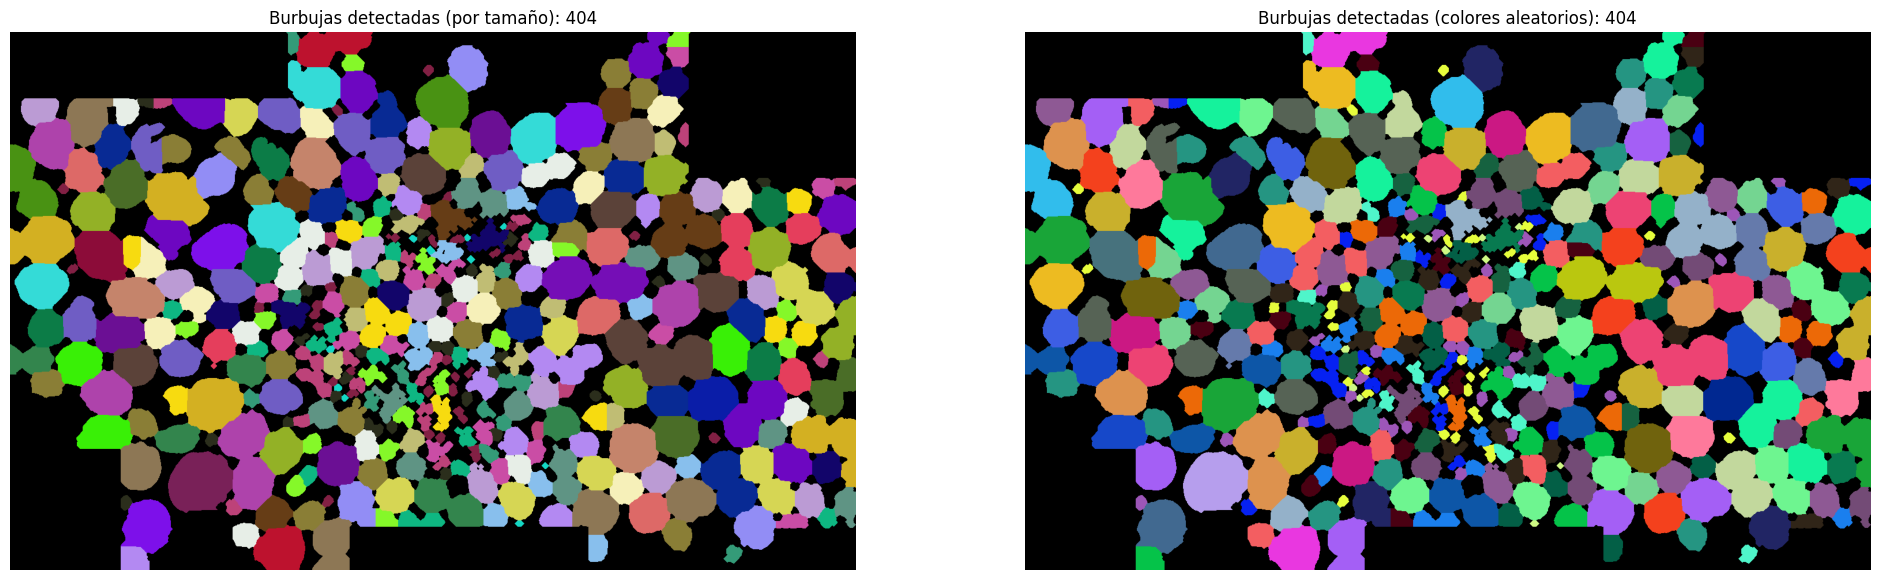

In [57]:
# Create a second colored result for random coloring
random_colored_result = np.zeros((labels.shape[0], labels.shape[1], 3), dtype=np.uint8)

gradient_colors = plt.cm.viridis(np.linspace(0, 1, len(areas)))  # Use a colormap
classifications = []


for i, (lbl, area) in enumerate(areas):
    color = get_color_by_increment(area, increment=150)
    classifications.append({"label": lbl, "area": area, "color": color})
    colored_result[labels == lbl] = color
    
    # Assign a random color
    random_color = (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255))
    random_colored_result[labels == lbl] = random_color

# Plot both images side by side
fig, axes = plt.subplots(1, 2, figsize=(24, 12))

# Image colored by size
axes[0].imshow(cv2.cvtColor(colored_result, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Burbujas detectadas (por tamaño): {valid_count}")
axes[0].axis('off')

# Image randomly colored
axes[1].imshow(cv2.cvtColor(random_colored_result, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Burbujas detectadas (colores aleatorios): {valid_count}")
axes[1].axis('off')

plt.show()

In [58]:
for entry in classifications:
    print(f"Label: {entry['label']}, Area: {entry['area']}, Color: {entry['color']}")

Label: 355, Area: 90, Color: (197, 215, 20)
Label: 97, Area: 91, Color: (197, 215, 20)
Label: 109, Area: 101, Color: (197, 215, 20)
Label: 290, Area: 111, Color: (197, 215, 20)
Label: 137, Area: 120, Color: (197, 215, 20)
Label: 399, Area: 127, Color: (197, 215, 20)
Label: 112, Area: 128, Color: (197, 215, 20)
Label: 275, Area: 143, Color: (197, 215, 20)
Label: 229, Area: 148, Color: (197, 215, 20)
Label: 123, Area: 149, Color: (197, 215, 20)
Label: 310, Area: 172, Color: (68, 32, 130)
Label: 256, Area: 176, Color: (68, 32, 130)
Label: 263, Area: 183, Color: (68, 32, 130)
Label: 268, Area: 192, Color: (68, 32, 130)
Label: 259, Area: 193, Color: (68, 32, 130)
Label: 69, Area: 197, Color: (68, 32, 130)
Label: 342, Area: 207, Color: (68, 32, 130)
Label: 124, Area: 208, Color: (68, 32, 130)
Label: 135, Area: 222, Color: (68, 32, 130)
Label: 201, Area: 222, Color: (68, 32, 130)
Label: 106, Area: 223, Color: (68, 32, 130)
Label: 113, Area: 227, Color: (68, 32, 130)
Label: 282, Area: 227, Col

Testing with more stricted when the values is superior to 40% in the final result with almost 1000 area plus 

In [59]:
# Calcular total de píxeles en la imagen
total_pixels = binary_opened.size  # Total de píxeles en la imagen

# Contar píxeles pintados (foreground) usando la imagen binaria
painted_pixels = np.count_nonzero(binary_opened)

# Calcular píxeles no pintados (background)
unpainted_pixels = total_pixels - painted_pixels

# Calcular porcentaje de píxeles no pintados
unpainted_percentage = (unpainted_pixels / total_pixels) * 100
unpainted_percentage_adjust  = unpainted_percentage - 15.35

print(f"Porcentaje no pintado: {unpainted_percentage_adjust:.2f}%")
#[40%] minimo 61.75%maximo - No pintado, Ignorar igual < 18% -[21], Then 21% < Acceptable < 40% (Margen of 15.35 less due the noise)

Porcentaje no pintado: 16.66%


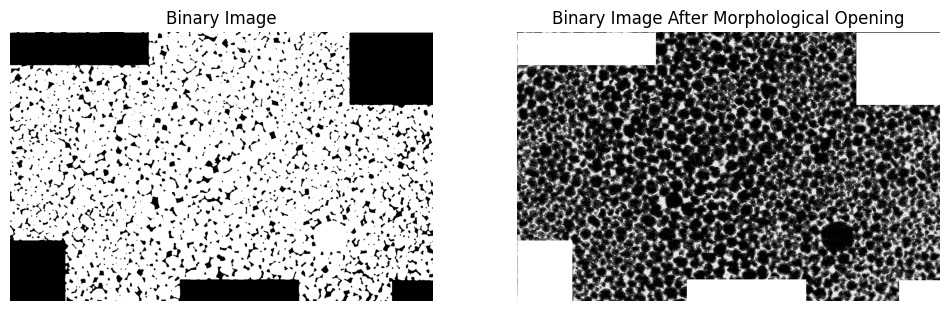

In [60]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from scipy import ndimage
from skimage.segmentation import watershed
from skimage.feature import peak_local_max

image_path = r'XY_clean\Batch(81-90)\xy082.jpg'
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Definir umbrales
max_area_threshold = 11000  # Maximum area for filtering
min_area_threshold = 0      # Minimum area for filtering

# 1. Suavizar la imagen para reducir ruido
blur = cv2.GaussianBlur(image, (9, 9), 0)  # Adjust kernel size and sigma to control smoothing
#This part can be for the first part 0-10
use_otsu = False  # Set to False if you want to configure manual thresholds
if use_otsu:
    _, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
else:
    manual_threshold = 160  # Adjust this value for manual thresholding
    _, binary = cv2.threshold(blur, manual_threshold, 255, cv2.THRESH_BINARY)

binary = cv2.bitwise_not(binary)  # Optional: Invert binary (if needed)

# Display the binary image
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(binary, cmap='gray')
plt.title("Binary Image")
plt.axis('off')

# 3. Operaciones morfológicas para limpiar pequeñas manchas y separar un poco las burbujas
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))  # Adjust kernel size
binary_opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=5)

# Display the morphologically opened binary image
plt.subplot(1, 2, 2)
plt.imshow(image, cmap='gray')
plt.title("Binary Image After Morphological Opening")
plt.axis('off')
plt.show()


OBSERVATIONS :
1. Making by sorting for size and be strictier by that cannot be done due the images well classified can have those conditions but be well done. 
2. The differce need to be at least for every 100 of area due to posteriory images where most of the bubbles are down to 1000 
3. I can set perfectly the conditions of white and black that ensure me a better images in binary images.  Meaning I can save images from 0 to 7
4. By defining per percentage I might save the last ones 
5. It was consider an automatizate learning but due it was only 5 images that really require, and cost a lot of time and complexity. It wise to stick to the defined methodology and try to apply CLAHE and adaptative filters
6. The method of using CLAHE and adaptive binary not worked in the last 5, however it might be worth it to try the the other images